# Single-Asset Model Comparison (BTC/USDT)

Compare buy-and-hold, SMA crossover, econometric (AR), and ML direction models on the same **test period**. Business logic lives in `src/crypto_hf/`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

from crypto_hf.config import load_single_asset_models_config
from crypto_hf.pipeline.single_asset_models import (
    prepare_model_dataset,
    run_single_asset_models_pipeline,
)
from crypto_hf.pipeline.baseline import split_train_test
from crypto_hf.visualization.plots import plot_equity_curve, plot_drawdown_comparison

plt.style.use("seaborn-v0_8-whitegrid")

## 1. Load config

In [2]:
config = load_single_asset_models_config(PROJECT_ROOT / "configs" / "single_asset_models.yaml")
config

SingleAssetModelsConfig(symbol='BTC/USDT', timeframe='1d', data_path=PosixPath('/home/gwyllan/projects/ai-crypto-hedge-fund/data/raw/BTC_USDT_1d.csv'), initial_cash=10000.0, fee_rate=0.001, slippage=0.0, train_size=0.7, fast_window=10, slow_window=30, volatility_window=20, annualization_factor=365, return_lags=[1, 2, 3, 5], rolling_mean_windows=[5, 10, 20], rolling_vol_windows=[10, 20], momentum_windows=[5, 10, 20], sma_ratio_windows=[10, 20], rsi_window=14, econometric_lags=5, econometric_use_cost_threshold=True, ml_probability_threshold=0.5, logistic_regression_c=1.0, logistic_regression_max_iter=1000, enable_random_forest=True, random_forest_n_estimators=100)

## 2. Features and target summary

In [3]:
from crypto_hf.data.loader import load_ohlcv_csv

raw = load_ohlcv_csv(config.data_path)
dataset, feature_cols = prepare_model_dataset(raw, config)
train, test = split_train_test(dataset, config.train_size)
print(f"Features: {len(feature_cols)}")
print(f"Train: {len(train)} | Test: {len(test)}")
dataset[["returns", "next_return", "target_up"] + feature_cols[:5]].tail()

Features: 14
Train: 685 | Test: 294


,returns,next_return,target_up,return_lag_1,return_lag_2,return_lag_3,return_lag_5,rolling_mean_return_5
timestamp,,,,,,,,
2026-06-14 00:00:00+00:00,0.019989,0.008857,1,0.013809,-0.000723,0.034384,-0.021494,0.012782
2026-06-15 00:00:00+00:00,0.008857,-0.009856,0,0.019989,0.013809,-0.000723,-0.003548,0.015263
2026-06-16 00:00:00+00:00,-0.009856,-0.017748,0,0.008857,0.019989,0.013809,0.034384,0.006415
2026-06-17 00:00:00+00:00,-0.017748,-0.024049,0,-0.009856,0.008857,0.019989,-0.000723,0.003010
2026-06-18 00:00:00+00:00,-0.024049,-0.001620,0,-0.017748,-0.009856,0.008857,0.013809,-0.004562


## 3. Run full model pipeline

In [4]:
outputs = run_single_asset_models_pipeline(config, reports_dir=PROJECT_ROOT / "reports")
outputs.trading_metrics

,total_return,cagr,annualized_volatility,sharpe_ratio,sortino_ratio,max_drawdown,calmar_ratio,number_of_trades,turnover
strategy,,,,,,,,,
buy_and_hold,-0.422007,-0.494851,0.451260,-1.280058,-1.726541,-0.511589,-0.967283,1.0,1.0
sma_crossover,-0.178929,-0.217758,0.236753,-0.914968,-0.867014,-0.240891,-0.903968,6.0,12.0
econometric_autoreg,-0.193277,-0.234750,0.366343,-0.546196,-0.757759,-0.369431,-0.635437,64.0,127.0
ml_logistic_regression,-0.384594,-0.453800,0.395750,-1.322518,-1.586790,-0.422449,-1.074214,56.0,111.0
ml_random_forest,-0.466827,-0.543175,0.376535,-1.881404,-2.092808,-0.503512,-1.078772,49.0,97.0


## 4. Classification diagnostics

In [5]:
outputs.classification_metrics

,accuracy,precision,recall,f1,confusion_tn,confusion_fp,confusion_fn,confusion_tp,roc_auc
model,,,,,,,,,
econometric_autoreg,0.503401,0.483568,0.741007,0.585227,45.0,110.0,36.0,103.0,NaN
ml_logistic_regression,0.431973,0.429293,0.611511,0.504451,42.0,113.0,54.0,85.0,0.443073
ml_random_forest,0.418367,0.413043,0.546763,0.470588,47.0,108.0,63.0,76.0,0.417823


## 5. Equity and drawdown comparison

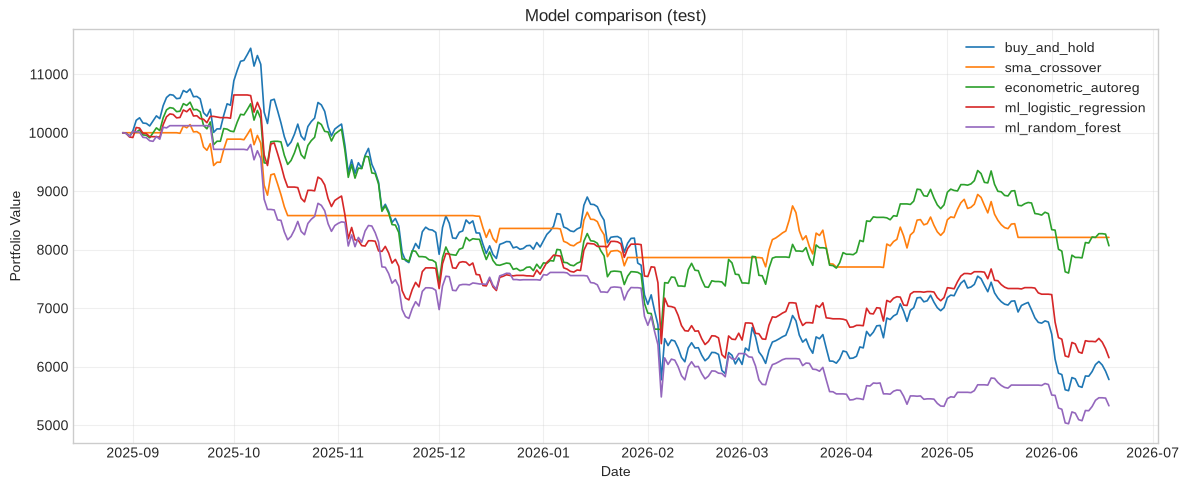

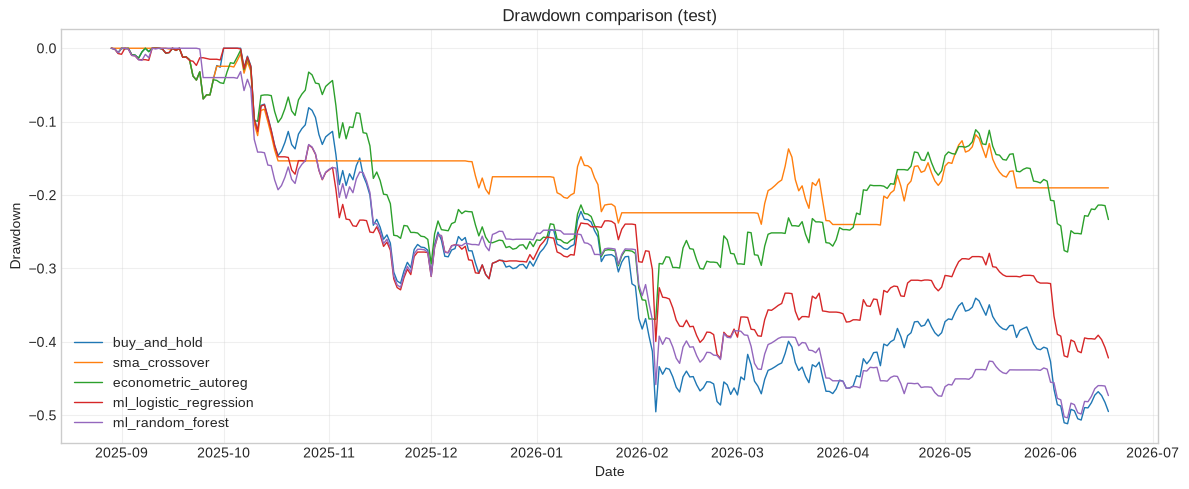

In [6]:
equity = {name: r.equity_curve for name, r in outputs.results.items()}
plot_equity_curve(equity, title="Model comparison (test)")
plot_drawdown_comparison(equity, title="Drawdown comparison (test)")
plt.show()

## 6. Interpretation

Weak or negative financial performance is expected for naive direction models on daily BTC. The goal of this block is **correct integration** of econometric and ML signals into the existing backtest pipeline:

- chronological train/test split;
- no look-ahead (`position = signal.shift(1)`);
- shared `VectorbtBacktester` and trading metrics;
- classification metrics as diagnostics only.

Next steps: walk-forward validation, richer features, and eventually agent orchestration — not in this block.